# Aulão LLM's e Agentes - Langgraph

Nessa aula, eu me baseei no tutorial oficial do Langgraph para construir um chatbot de suporte ao cliente para uma companhia aérea. Eu achei melhor manter o contexto e não trocar para o da Lumni porque eles usam base de dados e tal, eu suguei de fazer com os dados da Lumni e as coisas que eu vou mostrar são bem maneiras, então vamos manter o contexto deles.


> Bots de suporte ao cliente podem liberar o tempo das equipes ao lidar com problemas rotineiros, mas pode ser difícil construir um chatbot que lide de forma confiável com tarefas diversas. Vamos tentar fazer isso. 

Neste tutorial, vamos construir um sistema bem complexo pra tentar provar o conceito. A missão do(s) assistente(s) nesse notebook é atuar como um bot de suporte ao cliente de uma empresa de viagens, ajudando o usuário a:

- Entender políticas da empresa antes de fazer alterações;
- Consultar informações de voos e bilhetes do usuário;
- Pesquisar / reservar / alterar / cancelar: aluguel de carro, hotel e excursões/passeios;
- (Quando necessário) buscar informações gerais na web via Tavily;
- Evoluir de um agente “único” para uma arquitetura com assistentes especializados (supervisor/roteador + especialistas).

O esquema do projeto final será parecido com:
<img src="./Images/esquema_geral_chat.png">


## Afinal, o que vamos fazer?

### [Parte 0 — Introdução](#parte-0)
- Apresentamos o **objetivo do projeto** (chatbot de suporte para viagens).
- Carregamos e preparamos os recursos do sistema:
  - **Banco SQLite** (dados de voos, hotéis, carros e passeios).
  - **Base de políticas** (retriever) para consulta de regras da empresa.
- Definimos e registramos as **tools** (funções) que os agentes podem chamar.


### [Parte 1 — Agente Zero-shot (base)](#parte-1)
- Criamos um **agente único** que interpreta a mensagem do usuário.
- O agente decide entre:
  - responder diretamente, ou
  - chamar uma **tool** (consultar políticas ou consultar/alterar dados no banco).
- Integramos o agente a um fluxo básico de conversa (estado + grafo).


### [Parte 2 — Confirmação antes de ações (safety)](#parte-2)
- Adicionamos um mecanismo de **confirmação explícita** do usuário.
- Antes de operações sensíveis (ex.: **reservar, alterar, cancelar**), o bot:
  - explica o que pretende fazer,
  - pede confirmação antes de executar.


### [Parte 3 — Interrupção Condicional (pause/resume)](#parte-3)
- Implementamos um controle mais robusto:
  - o grafo **pausa automaticamente** quando a próxima etapa envolver uma tool “de escrita”.
- O usuário confirma (ou recusa) e o fluxo:
  - **retoma do ponto exato** (checkpoint/resume),
  - reduzindo repetição e riscos.


### [Parte 4 — Assistentes Especializados (multiagente)](#parte-4)
- Evoluímos para um **time de especialistas**:
  - Voos, Hotéis, Carros, Passeios/Excursões.
- Criamos um **Assistente Principal (roteador/supervisor)** que:
  - identifica a intenção do usuário,
  - encaminha ao especialista correto,
  - retorna ao fluxo principal ao terminar.
- Cada especialista usa **apenas as tools relevantes**, aumentando confiabilidade e modularidade.


<a id="parte-0"></a>
### Parte 0 — Introdução

In [1]:
from dotenv import load_dotenv
# você deve configurar suas variáveis de ambiente no .env
load_dotenv()

True

> Configure o <a href="https://smith.langchain.com">LangSmith</a> para a gente fazer o tracing para fazer debugging, ver todas as chamadas dos agentes -- essa é a maneira profissional de fazer, evita de você ter que ficar printando tudo.

#### Preenchendo o banco de dados
A DB que utilizaremos é uma base “mock” de uma empresa de turismo, com dados suficientes para simular suporte real. Na base de dados existem pelo menos estas tabelas principais:

- **_flights_** (informações de voos)
- **_tickets_** (tickets/identificadores do usuário)
- **_ticket_flights_** (relação ticket ↔ voo)
- **_car_rentals_**
- **_hotels_**
- **_trip_recommendations_** (passeios/recomendações)
Para buscar um DB `sqlite` que usam no tutorial e atualizá-lo para que pareça atual(tipo agora), vamos fazer o seguinte:


In [4]:
import os
import shutil
import sqlite3
import pandas as pd 
import requests

# aqui tem o link se quiser baixar tbm
db_url = "https://storage.googleapis.com/benchmarks-artifacts/travel-db/travel2.sqlite"

local_file = "travel2.sqlite"
# O backup vai permitir reiniciar para cada seção
backup_file = "travel2.backup.sqlite"
overwrite = False
if overwrite or not os.path.exists(local_file):
    response = requests.get(db_url)
    response.raise_for_status()
    with open(local_file, "wb") as f:
        f.write(response.content)
    # Backup - vamos usar isso para "resetar" nosso DB em cada seção
    shutil.copy(local_file, backup_file)


# Converte os voos para o tempo presente
def update_dates(file):
    shutil.copy(backup_file, file)
    conn = sqlite3.connect(file)
    cursor = conn.cursor()

    tables = pd.read_sql(
        "SELECT name FROM sqlite_master WHERE type='table';", conn
    ).name.tolist()
    tdf = {}
    for t in tables:
        tdf[t] = pd.read_sql(f"SELECT * from {t}", conn)

    example_time = pd.to_datetime(
        tdf["flights"]["actual_departure"].replace("\\N", pd.NaT)
    ).max()
    current_time = pd.to_datetime("now").tz_localize(example_time.tz)
    time_diff = current_time - example_time

    tdf["bookings"]["book_date"] = (
        pd.to_datetime(tdf["bookings"]["book_date"].replace("\\N", pd.NaT), utc=True)
        + time_diff
    )

    datetime_columns = [
        "scheduled_departure",
        "scheduled_arrival",
        "actual_departure",
        "actual_arrival",
    ]
    for column in datetime_columns:
        tdf["flights"][column] = (
            pd.to_datetime(tdf["flights"][column].replace("\\N", pd.NaT)) + time_diff
        )

    for table_name, df in tdf.items():
        df.to_sql(table_name, conn, if_exists="replace", index=False)
    del df
    del tdf
    conn.commit()
    conn.close()

    return file


db = update_dates(local_file)


## Tools

Em seguida, vamos definir as tools do nosso assistente para buscar no manual de políticas da companhia aérea e pesquisar e gerenciar reservas de voos, hotéis, aluguéis de carros e excursões. Não foca muito na implementação nas tools, só olha e vê como elas funcionam e o que elas fazem.

#### Consultar Políticas da Empresa

O assistente recupera informações de políticas(está num faq em texto) para responder às perguntas do usuário. Então aqui nós vamos fazer um RAG(aula anterior).

In [7]:
import re
import requests
from langchain_core.tools import tool
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

# baixa o FAQ de políticas da empresa
response = requests.get(
    "https://storage.googleapis.com/benchmarks-artifacts/travel-db/swiss_faq.md"
)
response.raise_for_status()
faq_text = response.text

# separa por seções (cada seção começa com "##")
docs = [{"page_content": txt} for txt in re.split(r"(?=\n##)", faq_text)]

# vamos fazer o RAG igual na aula anterior, só vamos encapsular num classe
# retriever baseado em vetores
class VectorStoreRetriever:
    def __init__(self, docs: list[dict], vectorstore: FAISS):
        self._docs = docs
        self._vs = vectorstore

    @classmethod
    def from_docs(cls, docs: list[dict]):
        # embeddings da OpenAI
        embeddings = OpenAIEmbeddings()

        # converte p/ Document e guarda o índice original
        documents = [
            Document(page_content=d["page_content"], metadata={"doc_id": i})
            for i, d in enumerate(docs)
        ]
        # Usamos FAISS também
        vectorstore = FAISS.from_documents(documents, embeddings)
        return cls(docs, vectorstore)

    def query(self, query: str, k: int = 5) -> list[dict]:
        # retorna score de relevância
        results = self._vs.similarity_search_with_relevance_scores(query, k=k)

        out = []
        for doc, score in results:
            idx = doc.metadata.get("doc_id")
            base = self._docs[idx] if idx is not None else {"page_content": doc.page_content}
            out.append({**base, "similarity": float(score)})

        return out

retriever = VectorStoreRetriever.from_docs(docs)

@tool
def lookup_policy(query: str) -> str:
    """Consult the company policies to check whether certain options are permitted.
    Use this before making any flight changes performing other 'write' events."""
    docs = retriever.query(query, k=2)
    return "\n\n".join([doc["page_content"] for doc in docs])

#### Voos

- **`fetch_user_flight_information`**  
  Busca todos os bilhetes do passageiro logado e retorna, para cada bilhete, os dados do voo associado e o assento atribuído.

- **`search_flights`**  
  Consulta a tabela de voos para listar opções compatíveis com filtros de origem, destino e janela de horário de partida.

- **`update_ticket_to_new_flight`**  
  Remarca um bilhete existente para um novo voo (validando existência do voo, propriedade do bilhete e restrições de horário antes de atualizar no banco).

- **`cancel_ticket`**  
  Cancela o bilhete do usuário (validando existência e propriedade) e remove a reserva correspondente do banco.

Para garantir isolamento entre usuários, as tools usam o [`RunnableConfig`](https://python.langchain.com/docs/how_to/tool_configure/#inferring-by-parameter-type) para obter o `passenger_id` do usuário logado durante a execução do grafo. Assim, a LLM **não precisa informar** esse identificador; ele é injetado pela aplicação a cada invocação, impedindo que um usuário acesse reservas de outro.

In [8]:
import sqlite3
from datetime import date, datetime
from typing import Optional

import pytz
from langchain_core.runnables import RunnableConfig


@tool
def fetch_user_flight_information(config: RunnableConfig) -> list[dict]:
    """ Busca todos os bilhetes do usuário junto com as informações de voo e assentos correspondentes.

    Retorna:
        Uma lista de dicionários onde cada dicionário contém os detalhes do bilhete,
        detalhes do voo associado e as atribuições de assentos para cada bilhete pertencente ao usuário.
    """
    configuration = config.get("configurable", {})
    passenger_id = configuration.get("passenger_id", None)
    if not passenger_id:
        raise ValueError("No passenger ID configured.")

    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    # aqui tem a query certinha que vamos usar
    query = """
    SELECT 
        t.ticket_no, t.book_ref,
        f.flight_id, f.flight_no, f.departure_airport, f.arrival_airport, f.scheduled_departure, f.scheduled_arrival,
        bp.seat_no, tf.fare_conditions
    FROM 
        tickets t
        JOIN ticket_flights tf ON t.ticket_no = tf.ticket_no
        JOIN flights f ON tf.flight_id = f.flight_id
        JOIN boarding_passes bp ON bp.ticket_no = t.ticket_no AND bp.flight_id = f.flight_id
    WHERE 
        t.passenger_id = ?
    """
    cursor.execute(query, (passenger_id,))
    rows = cursor.fetchall()
    column_names = [column[0] for column in cursor.description]
    results = [dict(zip(column_names, row)) for row in rows]

    cursor.close()
    conn.close()

    return results


@tool
def search_flights(
    departure_airport: Optional[str] = None,
    arrival_airport: Optional[str] = None,
    start_time: Optional[date | datetime] = None,
    end_time: Optional[date | datetime] = None,
    limit: int = 20,
) -> list[dict]:
    """Busca voos com base no aeroporto de partida, aeroporto de chegada e intervalo de horário de partida."""
    conn = sqlite3.connect(db)
    cursor = conn.cursor()
     # esse 1 = 1 é bizu pra gente concatenar com as condições sem dar erro
    query = "SELECT * FROM flights WHERE 1 = 1"
    params = []

    if departure_airport:
        query += " AND departure_airport = ?"
        params.append(departure_airport)

    if arrival_airport:
        query += " AND arrival_airport = ?"
        params.append(arrival_airport)

    if start_time:
        query += " AND scheduled_departure >= ?"
        params.append(start_time)

    if end_time:
        query += " AND scheduled_departure <= ?"
        params.append(end_time)
    query += " LIMIT ?"
    params.append(limit)
    cursor.execute(query, params)
    rows = cursor.fetchall()
    column_names = [column[0] for column in cursor.description]
    results = [dict(zip(column_names, row)) for row in rows]

    cursor.close()
    conn.close()

    return results


@tool
def update_ticket_to_new_flight(
    ticket_no: str, new_flight_id: int, *, config: RunnableConfig
) -> str:
    """Atualiza o bilhete do usuário para um novo voo válido."""
    configuration = config.get("configurable", {})
    passenger_id = configuration.get("passenger_id", None)
    if not passenger_id:
        raise ValueError("No passenger ID configured.")

    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "SELECT departure_airport, arrival_airport, scheduled_departure FROM flights WHERE flight_id = ?",
        (new_flight_id,),
    )
    new_flight = cursor.fetchone()
    if not new_flight:
        cursor.close()
        conn.close()
        return "Invalid new flight ID provided."
    column_names = [column[0] for column in cursor.description]
    new_flight_dict = dict(zip(column_names, new_flight))
    timezone = pytz.timezone("Etc/GMT-3")
    current_time = datetime.now(tz=timezone)
    departure_time = datetime.strptime(
        new_flight_dict["scheduled_departure"], "%Y-%m-%d %H:%M:%S.%f%z"
    )
    time_until = (departure_time - current_time).total_seconds()
    if time_until < (3 * 3600):
        return f"Not permitted to reschedule to a flight that is less than 3 hours from the current time. Selected flight is at {departure_time}."

    cursor.execute(
        "SELECT flight_id FROM ticket_flights WHERE ticket_no = ?", (ticket_no,)
    )
    current_flight = cursor.fetchone()
    if not current_flight:
        cursor.close()
        conn.close()
        return "No existing ticket found for the given ticket number."

    # Confere se o usuário logado realmente tem esse bilhete
    cursor.execute(
        "SELECT * FROM tickets WHERE ticket_no = ? AND passenger_id = ?",
        (ticket_no, passenger_id),
    )
    current_ticket = cursor.fetchone()
    if not current_ticket:
        cursor.close()
        conn.close()
        return f"Current signed-in passenger with ID {passenger_id} not the owner of ticket {ticket_no}"

    cursor.execute(
        "UPDATE ticket_flights SET flight_id = ? WHERE ticket_no = ?",
        (new_flight_id, ticket_no),
    )
    conn.commit()

    cursor.close()
    conn.close()
    return "Ticket successfully updated to new flight."


@tool
def cancel_ticket(ticket_no: str, *, config: RunnableConfig) -> str:
    """Cancel the user's ticket and remove it from the database."""
    configuration = config.get("configurable", {})
    passenger_id = configuration.get("passenger_id", None)
    if not passenger_id:
        raise ValueError("No passenger ID configured.")
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "SELECT flight_id FROM ticket_flights WHERE ticket_no = ?", (ticket_no,)
    )
    existing_ticket = cursor.fetchone()
    if not existing_ticket:
        cursor.close()
        conn.close()
        return "No existing ticket found for the given ticket number."

    # Check the signed-in user actually has this ticket
    cursor.execute(
        "SELECT ticket_no FROM tickets WHERE ticket_no = ? AND passenger_id = ?",
        (ticket_no, passenger_id),
    )
    current_ticket = cursor.fetchone()
    if not current_ticket:
        cursor.close()
        conn.close()
        return f"Current signed-in passenger with ID {passenger_id} not the owner of ticket {ticket_no}"

    cursor.execute("DELETE FROM ticket_flights WHERE ticket_no = ?", (ticket_no,))
    conn.commit()

    cursor.close()
    conn.close()
    return "Ticket successfully cancelled."

#### Ferramentas de Aluguel de Carro

Uma vez que um usuário reserve um voo, provavelmente vai querer organizar o transporte. Definimos algumas ferramentas de "aluguel de carro" para permitir que o usuário pesquise e reserve um carro no destino.


In [9]:
from datetime import date, datetime
from typing import Optional, Union


@tool
def search_car_rentals(
    location: Optional[str] = None,
    name: Optional[str] = None,
    price_tier: Optional[str] = None,
    start_date: Optional[Union[datetime, date]] = None,
    end_date: Optional[Union[datetime, date]] = None,
) -> list[dict]:
    """
    Search for car rentals based on location, name, price tier, start date, and end date.

    Args:
        location (Optional[str]): The location of the car rental. Defaults to None.
        name (Optional[str]): The name of the car rental company. Defaults to None.
        price_tier (Optional[str]): The price tier of the car rental. Defaults to None.
        start_date (Optional[Union[datetime, date]]): The start date of the car rental. Defaults to None.
        end_date (Optional[Union[datetime, date]]): The end date of the car rental. Defaults to None.

    Returns:
        list[dict]: A list of car rental dictionaries matching the search criteria.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM car_rentals WHERE 1=1"
    params = []

    if location:
        query += " AND location LIKE ?"
        params.append(f"%{location}%")
    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")
    # For our tutorial, we will let you match on any dates and price tier.
    # (since our toy dataset doesn't have much data)
    cursor.execute(query, params)
    results = cursor.fetchall()

    conn.close()

    return [
        dict(zip([column[0] for column in cursor.description], row)) for row in results
    ]


@tool
def book_car_rental(rental_id: int) -> str:
    """
    Book a car rental by its ID.

    Args:
        rental_id (int): The ID of the car rental to book.

    Returns:
        str: A message indicating whether the car rental was successfully booked or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE car_rentals SET booked = 1 WHERE id = ?", (rental_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Car rental {rental_id} successfully booked."
    else:
        conn.close()
        return f"No car rental found with ID {rental_id}."


@tool
def update_car_rental(
    rental_id: int,
    start_date: Optional[Union[datetime, date]] = None,
    end_date: Optional[Union[datetime, date]] = None,
) -> str:
    """
    Update a car rental's start and end dates by its ID.

    Args:
        rental_id (int): The ID of the car rental to update.
        start_date (Optional[Union[datetime, date]]): The new start date of the car rental. Defaults to None.
        end_date (Optional[Union[datetime, date]]): The new end date of the car rental. Defaults to None.

    Returns:
        str: A message indicating whether the car rental was successfully updated or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    if start_date:
        cursor.execute(
            "UPDATE car_rentals SET start_date = ? WHERE id = ?",
            (start_date, rental_id),
        )
    if end_date:
        cursor.execute(
            "UPDATE car_rentals SET end_date = ? WHERE id = ?", (end_date, rental_id)
        )

    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Car rental {rental_id} successfully updated."
    else:
        conn.close()
        return f"No car rental found with ID {rental_id}."


@tool
def cancel_car_rental(rental_id: int) -> str:
    """
    Cancel a car rental by its ID.

    Args:
        rental_id (int): The ID of the car rental to cancel.

    Returns:
        str: A message indicating whether the car rental was successfully cancelled or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE car_rentals SET booked = 0 WHERE id = ?", (rental_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Car rental {rental_id} successfully cancelled."
    else:
        conn.close()
        return f"No car rental found with ID {rental_id}."

#### Hotéis

O usuário precisa dormir! Definimos algumas ferramentas para pesquisar e gerenciar reservas de hotel.


In [10]:
@tool
def search_hotels(
    location: Optional[str] = None,
    name: Optional[str] = None,
    price_tier: Optional[str] = None,
    checkin_date: Optional[Union[datetime, date]] = None,
    checkout_date: Optional[Union[datetime, date]] = None,
) -> list[dict]:
    """
    Search for hotels based on location, name, price tier, check-in date, and check-out date.

    Args:
        location (Optional[str]): The location of the hotel. Defaults to None.
        name (Optional[str]): The name of the hotel. Defaults to None.
        price_tier (Optional[str]): The price tier of the hotel. Defaults to None. Examples: Midscale, Upper Midscale, Upscale, Luxury
        checkin_date (Optional[Union[datetime, date]]): The check-in date of the hotel. Defaults to None.
        checkout_date (Optional[Union[datetime, date]]): The check-out date of the hotel. Defaults to None.

    Returns:
        list[dict]: A list of hotel dictionaries matching the search criteria.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM hotels WHERE 1=1"
    params = []

    if location:
        query += " AND location LIKE ?"
        params.append(f"%{location}%")
    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")
    # For the sake of this tutorial, we will let you match on any dates and price tier.
    cursor.execute(query, params)
    results = cursor.fetchall()

    conn.close()

    return [
        dict(zip([column[0] for column in cursor.description], row)) for row in results
    ]


@tool
def book_hotel(hotel_id: int) -> str:
    """
    Book a hotel by its ID.

    Args:
        hotel_id (int): The ID of the hotel to book.

    Returns:
        str: A message indicating whether the hotel was successfully booked or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE hotels SET booked = 1 WHERE id = ?", (hotel_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Hotel {hotel_id} successfully booked."
    else:
        conn.close()
        return f"No hotel found with ID {hotel_id}."


@tool
def update_hotel(
    hotel_id: int,
    checkin_date: Optional[Union[datetime, date]] = None,
    checkout_date: Optional[Union[datetime, date]] = None,
) -> str:
    """
    Update a hotel's check-in and check-out dates by its ID.

    Args:
        hotel_id (int): The ID of the hotel to update.
        checkin_date (Optional[Union[datetime, date]]): The new check-in date of the hotel. Defaults to None.
        checkout_date (Optional[Union[datetime, date]]): The new check-out date of the hotel. Defaults to None.

    Returns:
        str: A message indicating whether the hotel was successfully updated or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    if checkin_date:
        cursor.execute(
            "UPDATE hotels SET checkin_date = ? WHERE id = ?", (checkin_date, hotel_id)
        )
    if checkout_date:
        cursor.execute(
            "UPDATE hotels SET checkout_date = ? WHERE id = ?",
            (checkout_date, hotel_id),
        )

    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Hotel {hotel_id} successfully updated."
    else:
        conn.close()
        return f"No hotel found with ID {hotel_id}."


@tool
def cancel_hotel(hotel_id: int) -> str:
    """
    Cancel a hotel by its ID.

    Args:
        hotel_id (int): The ID of the hotel to cancel.

    Returns:
        str: A message indicating whether the hotel was successfully cancelled or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute("UPDATE hotels SET booked = 0 WHERE id = ?", (hotel_id,))
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Hotel {hotel_id} successfully cancelled."
    else:
        conn.close()
        return f"No hotel found with ID {hotel_id}."

#### Excursões

Por fim, defina algumas ferramentas para permitir que o usuário pesquise coisas para fazer (e faça reservas) quando chegar.


In [11]:
@tool
def search_trip_recommendations(
    location: Optional[str] = None,
    name: Optional[str] = None,
    keywords: Optional[str] = None,
) -> list[dict]:
    """
    Search for trip recommendations based on location, name, and keywords.

    Args:
        location (Optional[str]): The location of the trip recommendation. Defaults to None.
        name (Optional[str]): The name of the trip recommendation. Defaults to None.
        keywords (Optional[str]): The keywords associated with the trip recommendation. Defaults to None.

    Returns:
        list[dict]: A list of trip recommendation dictionaries matching the search criteria.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    query = "SELECT * FROM trip_recommendations WHERE 1=1"
    params = []

    if location:
        query += " AND location LIKE ?"
        params.append(f"%{location}%")
    if name:
        query += " AND name LIKE ?"
        params.append(f"%{name}%")
    if keywords:
        keyword_list = keywords.split(",")
        keyword_conditions = " OR ".join(["keywords LIKE ?" for _ in keyword_list])
        query += f" AND ({keyword_conditions})"
        params.extend([f"%{keyword.strip()}%" for keyword in keyword_list])

    cursor.execute(query, params)
    results = cursor.fetchall()

    conn.close()

    return [
        dict(zip([column[0] for column in cursor.description], row)) for row in results
    ]


@tool
def book_excursion(recommendation_id: int) -> str:
    """
    Book an excursion by its recommendation ID.

    Args:
        recommendation_id (int): The ID of the trip recommendation to book.

    Returns:
        str: A message indicating whether the trip recommendation was successfully booked or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "UPDATE trip_recommendations SET booked = 1 WHERE id = ?", (recommendation_id,)
    )
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Trip recommendation {recommendation_id} successfully booked."
    else:
        conn.close()
        return f"No trip recommendation found with ID {recommendation_id}."


@tool
def update_excursion(recommendation_id: int, details: str) -> str:
    """
    Update a trip recommendation's details by its ID.

    Args:
        recommendation_id (int): The ID of the trip recommendation to update.
        details (str): The new details of the trip recommendation.

    Returns:
        str: A message indicating whether the trip recommendation was successfully updated or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "UPDATE trip_recommendations SET details = ? WHERE id = ?",
        (details, recommendation_id),
    )
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Trip recommendation {recommendation_id} successfully updated."
    else:
        conn.close()
        return f"No trip recommendation found with ID {recommendation_id}."


@tool
def cancel_excursion(recommendation_id: int) -> str:
    """
    Cancel a trip recommendation by its ID.

    Args:
        recommendation_id (int): The ID of the trip recommendation to cancel.

    Returns:
        str: A message indicating whether the trip recommendation was successfully cancelled or not.
    """
    conn = sqlite3.connect(db)
    cursor = conn.cursor()

    cursor.execute(
        "UPDATE trip_recommendations SET booked = 0 WHERE id = ?", (recommendation_id,)
    )
    conn.commit()

    if cursor.rowcount > 0:
        conn.close()
        return f"Trip recommendation {recommendation_id} successfully cancelled."
    else:
        conn.close()
        return f"No trip recommendation found with ID {recommendation_id}."

#### Utilitários

Defina funções auxiliares para imprimir de forma legível as mensagens no grafo enquanto fazemos depuração e para dar ao nosso nó de ferramentas tratamento de erros (adicionando o erro ao histórico do chat).


In [12]:
from langchain_core.messages import ToolMessage
from langchain_core.runnables import RunnableLambda

from langgraph.prebuilt import ToolNode


def handle_tool_error(state) -> dict:
    error = state.get("error")
    tool_calls = state["messages"][-1].tool_calls
    return {
        "messages": [
            ToolMessage(
                content=f"Error: {repr(error)}\n please fix your mistakes.",
                tool_call_id=tc["id"],
            )
            for tc in tool_calls
        ]
    }


def create_tool_node_with_fallback(tools: list) -> dict:
    return ToolNode(tools).with_fallbacks(
        [RunnableLambda(handle_tool_error)], exception_key="error"
    )


def _print_event(event: dict, _printed: set, max_length=1500):
    current_state = event.get("dialog_state")
    if current_state:
        print("Currently in: ", current_state[-1])
    message = event.get("messages")
    if message:
        if isinstance(message, list):
            message = message[-1]
        if message.id not in _printed:
            msg_repr = message.pretty_repr(html=True)
            if len(msg_repr) > max_length:
                msg_repr = msg_repr[:max_length] + " ... (truncated)"
            print(msg_repr)
            _printed.add(message.id)

<a id="parte-1"></a>
## Parte 1: Agente Zero-shot

A primeira versão do chatbot vai ser a mais simples que dá: um agente Zero-shot.

Como é um grafo “único”, ele tem alguns problemas: pode tentar fazer coisas sem pedir confirmação, pode se perder em perguntas mais complicadas e às vezes responde sem tanto foco. Vamos ajustar isso nas próximas partes.

Nesta parte, vamos definir um assistente Zero-shot e liberar **todas** as tools para ele usar — mas com instruções para usar com bom senso.

O grafo inicial tem só 2 nós:

<img src="./Images/part-1.png">

Vamos começar definindo o **estado**.

#### Estado
O estado do `StateGraph` será um dicionário tipado com uma lista de mensagens (append-only). Esse histórico do chat é o suficiente para o nosso assistente nesta etapa.

In [12]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph.message import AnyMessage, add_messages


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

#### Agente

Em seguida, defina a função do assistente. Essa função recebe o estado do grafo, formata-o em um prompt e então chama um LLM para que ele preveja a melhor resposta.


In [15]:
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig


class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: State, config: RunnableConfig):
        while True:
            configuration = config.get("configurable", {})
            passenger_id = configuration.get("passenger_id", None)
            state = {**state, "user_info": passenger_id}
            result = self.runnable.invoke(state)
            # If the LLM happens to return an empty response, we will re-prompt it
            # for an actual response.
            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        return {"messages": result}


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

primary_assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Você é um assistente de suporte ao cliente útil da Swiss Airlines. "
            " Use as ferramentas fornecidas para buscar voos, políticas da empresa e outras informações para auxiliar as consultas dos usuários. "
            " Ao buscar, seja persistente. Expanda seus parâmetros de consulta se a primeira busca não retornar resultados. "
            " Se uma busca não retornar nada, expanda sua busca antes de desistir."
            "\n\nUsuário atual:\n<User>\n{user_info}\n</User>"
            "\nHorário atual: {time}.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

# tools da parte 1 que escrevemos
part_1_tools = [
    TavilySearchResults(max_results=1),
    fetch_user_flight_information,
    search_flights,
    lookup_policy,
    update_ticket_to_new_flight,
    cancel_ticket,
    search_car_rentals,
    book_car_rental,
    update_car_rental,
    cancel_car_rental,
    search_hotels,
    book_hotel,
    update_hotel,
    cancel_hotel,
    search_trip_recommendations,
    book_excursion,
    update_excursion,
    cancel_excursion,
]
part_1_assistant_runnable = primary_assistant_prompt | llm.bind_tools(part_1_tools)

#### Definir o Grafo

Agora, crie o grafo. O grafo é o assistente final para esta seção.


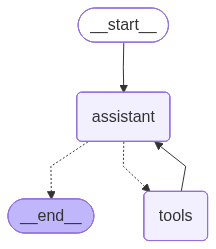

In [16]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import tools_condition
from IPython.display import Image, display

builder = StateGraph(State)


# Define nodes: these do the work
builder.add_node("assistant", Assistant(part_1_assistant_runnable))
builder.add_node("tools", create_tool_node_with_fallback(part_1_tools))
# Define edges: these determine how the control flow moves
builder.add_edge(START, "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools", "assistant")

# The checkpointer lets the graph persist its state
# this is a complete memory for the entire graph.
memory = InMemorySaver()
part_1_graph = builder.compile(checkpointer=memory)

# vamos ver o grafo
display(Image(part_1_graph.get_graph(xray=True).draw_mermaid_png()))

#### Exemplo de Conversa

Agora é hora de testar nosso poderoso chatbot! Vamos executá-lo sobre a seguinte lista de turnos de diálogo. Se ele atingir um "RecursionLimit", isso significa que o agente não conseguiu obter uma resposta no número de passos alocado. Tudo bem! Temos mais truques na manga em seções posteriores deste tutorial.

In [17]:
import shutil
import uuid

questions = [
    "Olá, que horas é o meu voo?",
    "Posso atualizar meu voo para algo mais cedo? Quero viajar ainda hoje.",
    "Então atualize meu voo para algum momento da próxima semana",
    "A próxima opção disponível está ótima",
    "E quanto a hospedagem e transporte?",
    "Sim, acho que gostaria de um hotel acessível para minha estadia de uma semana (7 dias). E vou querer alugar um carro.",
    "OK, você poderia fazer uma reserva no hotel recomendado? Parece bom.",
    "Sim, vá em frente e reserve qualquer coisa com preço moderado e disponibilidade.",
    "Agora para um carro, quais são minhas opções?",
    "Perfeito, vamos pegar a opção mais barata. Vá em frente e reserve por 7 dias",
    "Legal, então quais recomendações você tem para excursões?",
    "Elas estão disponíveis enquanto eu estiver lá?",
    "Interessante - gosto de museus, que opções há?",
    "OK ótimo, escolha um e reserve para meu segundo dia lá.",
]

# Update with the backup file so we can restart from the original place in each section
db = update_dates(db)
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # The passenger_id is used in our flight tools to
        # fetch the user's flight information
        "passenger_id": "3442 587242",
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}


_printed = set()
for question in questions:
    events = part_1_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)

================================ Human Message =================================

Olá, que horas é o meu voo?
================================== Ai Message ==================================
Tool Calls:
  fetch_user_flight_information (call_bDjAOA1C0ZrvenHcBtyiZQEQ)
 Call ID: call_bDjAOA1C0ZrvenHcBtyiZQEQ
  Args:
================================= Tool Message =================================
Name: fetch_user_flight_information

[{"ticket_no": "7240005432906569", "book_ref": "C46E9F", "flight_id": 19250, "flight_no": "LX0112", "departure_airport": "CDG", "arrival_airport": "BSL", "scheduled_departure": "2026-01-01 15:53:44.829357-04:00", "scheduled_arrival": "2026-01-01 17:23:44.829357-04:00", "seat_no": "18E", "fare_conditions": "Economy"}]
================================== Ai Message ==================================

Seu voo LX0112 está programado para decolar do aeroporto Charles de Gaulle (CDG) às 15:53 (horário local) e deve chegar ao aeroporto de Basel (BSL) às 17:23. Você est

O assistente é até bem daora, mas tem algumas preocupações, o ideal era ele validar algumas ações com o usuário antes de executar.

<a id="parte-2"></a>
## Parte 2: Adicionar Confirmação

Quando um assistente toma ações em nome do usuário, o usuário deve (quase) sempre ter a palavra final sobre se deve ou não seguir com as ações. Caso contrário, qualquer pequeno erro que o assistente cometa (ou qualquer prompt injection a que ele sucumba) pode causar danos reais ao usuário.

Nesta seção, vamos usar `interrupt_before` para pausar o grafo e devolver o controle ao usuário **antes** de executar qualquer uma das ferramentas.

Seu grafo será parecido com o seguinte:

<img src="./Images/part-2.png" src="./Images/part-2.png">

Como antes, comece definindo o estado:

#### Estado & Assistente

Nosso estado do grafo e a chamada ao LLM são quase idênticos à Parte 1, exceto por:

- Adicionamos um campo `user_info` que será preenchido de forma antecipada pelo nosso grafo
- Podemos usar o estado diretamente no objeto `Assistant` em vez de usar os parâmetros configuráveis


In [19]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig
from typing_extensions import TypedDict

from langgraph.graph.message import AnyMessage, add_messages


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    user_info: str


# aqui é igual ao Assistant da parte 1
class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: State, config: RunnableConfig):
        while True:
            result = self.runnable.invoke(state)
            # If the LLM happens to return an empty response, we will re-prompt it
            # for an actual response.
            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        return {"messages": result}


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Você é um assistente de suporte ao cliente útil da Swiss Airlines. "
            " Use as ferramentas fornecidas para buscar voos, políticas da empresa e outras informações para auxiliar as consultas dos usuários. "
            " Ao buscar, seja persistente. Expanda seus parâmetros de consulta se a primeira busca não retornar resultados. "
            " Se uma busca não retornar nada, expanda sua busca antes de desistir."
            "\n\nUsuário atual:\n<User>\n{user_info}\n</User>"
            "\nHorário atual: {time}.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

# são os mesmos da parte 1
part_2_tools = [
    TavilySearchResults(max_results=1),
    fetch_user_flight_information,
    search_flights,
    lookup_policy,
    update_ticket_to_new_flight,
    cancel_ticket,
    search_car_rentals,
    book_car_rental,
    update_car_rental,
    cancel_car_rental,
    search_hotels,
    book_hotel,
    update_hotel,
    cancel_hotel,
    search_trip_recommendations,
    book_excursion,
    update_excursion,
    cancel_excursion,
]
part_2_assistant_runnable = assistant_prompt | llm.bind_tools(part_2_tools)


#### Definir o Grafo

Agora, crie o grafo. Vamos fazer 2 mudanças em relação à parte 1 para tratar das nossas preocupações anteriores.

1. Adicionar uma interrupção antes de usar uma ferramenta
2. Preencher explicitamente o estado do usuário dentro do primeiro nó para que o assistente não precise usar uma ferramenta só para aprender sobre o usuário.


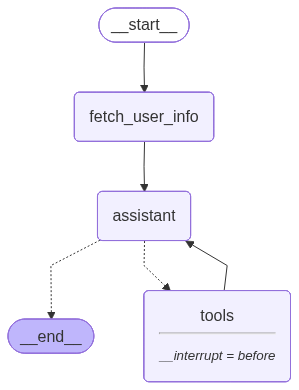

In [20]:
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)


def user_info(state: State):
    # o user_info é o dicionário de informações do usuário
    return {"user_info": fetch_user_flight_information.invoke({})}


# O fetch_user_info roda primeiro, então o assistente já vê as informações do usuário antes de precisar tomar uma ação

builder.add_node("fetch_user_info", user_info)
builder.add_edge(START, "fetch_user_info")
builder.add_node("assistant", Assistant(part_2_assistant_runnable))
builder.add_node("tools", create_tool_node_with_fallback(part_2_tools))
builder.add_edge("fetch_user_info", "assistant")
builder.add_conditional_edges(
    "assistant",
    tools_condition,
)
builder.add_edge("tools", "assistant")

memory = InMemorySaver()
part_2_graph = builder.compile(
    checkpointer=memory,

    # Agora colocampos o interrupt before, o grafo sempre para antes de executar a ferramenta "tools".
    # O usuário pode aprovar ou rejeitar (ou até alterar a solicitação) antes
    # o assistente continuar
    interrupt_before=["tools"],
)

display(Image(part_2_graph.get_graph(xray=True).draw_mermaid_png()))

In [21]:
import shutil
import uuid

# Update with the backup file so we can restart from the original place in each section
db = update_dates(db)
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # The passenger_id is used in our flight tools to
        # fetch the user's flight information
        "passenger_id": "3442 587242",
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}


_printed = set()

for question in questions:
    events = part_2_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)
    snapshot = part_2_graph.get_state(config)
    while snapshot.next:
        # We have an interrupt! The agent is trying to use a tool, and the user can approve or deny it
        # Note: This code is all outside of your graph. Typically, you would stream the output to a UI.
        # Then, you would have the frontend trigger a new run via an API call when the user has provided input.
        try:
            user_input = input(
                "Do you approve of the above actions? Type 'y' to continue;"
                " otherwise, explain your requested changed.\n\n"
            )
        except:
            user_input = "y"
        if user_input.strip() == "y":
            # Just continue
            result = part_2_graph.invoke(
                None,
                config,
            )
        else:
            # Satisfy the tool invocation by
            # providing instructions on the requested changes / change of mind
            result = part_2_graph.invoke(
                {
                    "messages": [
                        ToolMessage(
                            tool_call_id=event["messages"][-1].tool_calls[0]["id"],
                            content=f"API call denied by user. Reasoning: '{user_input}'. Continue assisting, accounting for the user's input.",
                        )
                    ]
                },
                config,
            )
        snapshot = part_2_graph.get_state(config)

================================ Human Message =================================

Olá, que horas é o meu voo?
================================== Ai Message ==================================

Seu voo LX0112 está agendado para decolar hoje, 1º de janeiro de 2026, às 18:08 (horário local). Você deve estar no aeroporto com antecedência para o embarque.
================================ Human Message =================================

Posso atualizar meu voo para algo mais cedo? Quero viajar ainda hoje.
================================== Ai Message ==================================
Tool Calls:
  search_flights (call_uDMppZ9i00c7Tl6tFu9yI0q7)
 Call ID: call_uDMppZ9i00c7Tl6tFu9yI0q7
  Args:
    departure_airport: CDG
    arrival_airport: BSL
    start_time: 2026-01-01T00:00:00
    end_time: 2026-01-01T18:08:00
    limit: 5
================================ Human Message =================================

Então atualize meu voo para algum momento da próxima semana
=============================

Legal, agora temos uma pré-confirmação antes de executar qualquer ação sensível, mas poxa, nem sempre precisamos dessa confirmação, né? Tipo, se o usuário só quer ver os detalhes do voo, não faz sentido pedir confirmação pra isso. Então na próxima seção, vamos reorganizar nosso grafo para que possamos interromper apenas nas ações "sensíveis" que de fato escrevem no banco de dados.

## Parte 3: Interrupção Condicional

De que maneiras poderíamos fazer essa condicional? Uma maneira simples seria separar nossas tools em duas categorias: ferramentas "safe" (somente leitura) e ferramentas "sensitive" (que modificam dados). Então, poderíamos configurar o grafo para interromper apenas antes de executar as ferramentas sensíveis.


Isso equilibra o controle do usuário e o fluxo conversacional, mas à medida que adicionamos mais ferramentas, nosso grafo único pode ficar complexo demais para esta estrutura "plana". Vamos tratar disso na próxima seção. 

Nosso grafo para a Parte 3 será parecido com o seguinte diagrama.

<img src="./Images/part-3.png" src="./Images/part-3.png">

#### Estado

Como sempre, comece definindo o estado do grafo. Nosso estado e a chamada ao LLM **são idênticos à** parte 2.

In [24]:
from typing import Annotated

from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig
from typing_extensions import TypedDict

from langgraph.graph.message import AnyMessage, add_messages

# state continua o mesmo;
class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    user_info: str


class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: State, config: RunnableConfig):
        while True:
            result = self.runnable.invoke(state)
            # If the LLM happens to return an empty response, we will re-prompt it
            # for an actual response.
            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        return {"messages": result}

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.8)

assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Você é um assistente de suporte ao cliente útil da Swiss Airlines. "
            " Use as ferramentas fornecidas para buscar voos, políticas da empresa e outras informações para auxiliar as consultas dos usuários. "
            " Ao buscar, seja persistente. Expanda seus parâmetros de consulta se a primeira busca não retornar resultados. "
            " Se uma busca não retornar nada, expanda sua busca antes de desistir."
            "\n\nUsuário atual:\n<User>\n{user_info}\n</User>"
            "\nHorário atual: {time}.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)


# tools de "Leitura", não modificam state - não precisam de confirmação do usuário
part_3_safe_tools = [
    TavilySearchResults(max_results=1),
    fetch_user_flight_information,
    search_flights,
    lookup_policy,
    search_car_rentals,
    search_hotels,
    search_trip_recommendations,
]

# Essas ferramentas todas alteram as reservas do usuário.
# O usuário tem o direito de controlar quais decisões são tomadas

part_3_sensitive_tools = [
    update_ticket_to_new_flight,
    cancel_ticket,
    book_car_rental,
    update_car_rental,
    cancel_car_rental,
    book_hotel,
    update_hotel,
    cancel_hotel,
    book_excursion,
    update_excursion,
    cancel_excursion,
]

sensitive_tool_names = {t.name for t in part_3_sensitive_tools}
part_3_assistant_runnable = assistant_prompt | llm.bind_tools(
    part_3_safe_tools + part_3_sensitive_tools
)

#### Definir o Grafo

Agora, crie o grafo. Nosso grafo é quase idêntico à parte 2 **exceto** que separamos as ferramentas em 2 nós distintos. Só interrompemos antes das ferramentas que de fato fazem mudanças nas reservas do usuário.


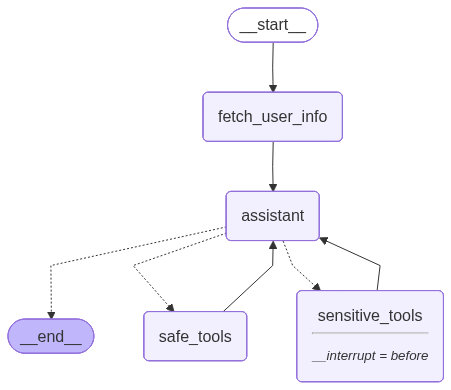

In [25]:
from typing import Literal

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph
from langgraph.prebuilt import tools_condition

builder = StateGraph(State)

def user_info(state: State):
    return {"user_info": fetch_user_flight_information.invoke({})}

# A tool fetch_user_info roda primeiro, então o assistente já vê as informações do usuário antes de precisar tomar uma ação

builder.add_node("fetch_user_info", user_info)
builder.add_edge(START, "fetch_user_info")
builder.add_node("assistant", Assistant(part_3_assistant_runnable))
builder.add_node("safe_tools", create_tool_node_with_fallback(part_3_safe_tools))
builder.add_node(
    "sensitive_tools", create_tool_node_with_fallback(part_3_sensitive_tools)
)
# Define logic
builder.add_edge("fetch_user_info", "assistant")


def route_tools(state: State):
    next_node = tools_condition(state)
    # Se não houver chamada de ferramenta, apenas retorne END
    if next_node == END:
        return END
    ai_message = state["messages"][-1]
    # Isso assume chamadas de ferramenta únicas. 
    # Para lidar com chamadas paralelas de ferramentas, você gostaria de usar ANY condition
    first_tool_call = ai_message.tool_calls[0]
    if first_tool_call["name"] in sensitive_tool_names:
        return "sensitive_tools"
    return "safe_tools"


builder.add_conditional_edges(
    "assistant", route_tools, ["safe_tools", "sensitive_tools", END]
)
builder.add_edge("safe_tools", "assistant")
builder.add_edge("sensitive_tools", "assistant")

memory = InMemorySaver()
part_3_graph = builder.compile(
    checkpointer=memory,
    # agora a interrupção acontece antes das ferramentas sensíveis
    interrupt_before=["sensitive_tools"],
)

display(Image(part_3_graph.get_graph(xray=True).draw_mermaid_png()))

In [26]:
import shutil
import uuid

# Update with the backup file so we can restart from the original place in each section
db = update_dates(db)
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # The passenger_id is used in our flight tools to
        # fetch the user's flight information
        "passenger_id": "3442 587242",
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}

questions = [
    "Olá, que horas é o meu voo?",
    "Posso atualizar meu voo para algo mais cedo? Quero viajar ainda hoje.",
    "Então atualize meu voo para algum momento da próxima semana",
    "A próxima opção disponível está ótima",
    "E quanto a hospedagem e transporte?",
    "Sim, acho que gostaria de um hotel acessível para minha estadia de uma semana (7 dias). E vou querer alugar um carro.",
    "OK, você poderia fazer uma reserva no hotel recomendado? Parece bom.",
    "Sim, vá em frente e reserve qualquer coisa com preço moderado e disponibilidade.",
    "Agora para um carro, quais são minhas opções?",
    "Perfeito, vamos pegar a opção mais barata. Vá em frente e reserve por 7 dias",
    "Legal, então quais recomendações você tem para excursões?",
    "Elas estão disponíveis enquanto eu estiver lá?",
    "Interessante - gosto de museus, que opções há?",
    "OK ótimo, escolha um e reserve para meu segundo dia lá.",
]


_printed = set()
# We can reuse the tutorial questions from part 1 to see how it does.
for question in questions:
    events = part_3_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)
    snapshot = part_3_graph.get_state(config)
    while snapshot.next:
        try:
            user_input = input(
                "Do you approve of the above actions? Type 'y' to continue;"
                " otherwise, explain your requested changed.\n\n"
            )
        except:
            user_input = "y"
        if user_input.strip() == "y":
            # Just continue
            result = part_3_graph.invoke(
                None,
                config,
            )
        else:
            # Satisfy the tool invocation by
            # providing instructions on the requested changes / change of mind
            result = part_3_graph.invoke(
                {
                    "messages": [
                        ToolMessage(
                            tool_call_id=event["messages"][-1].tool_calls[0]["id"],
                            content=f"API call denied by user. Reasoning: '{user_input}'. Continue assisting, accounting for the user's input.",
                        )
                    ]
                },
                config,
            )
        snapshot = part_3_graph.get_state(config)

================================ Human Message =================================

Olá, que horas é o meu voo?
================================== Ai Message ==================================

Seu voo LX0112 está programado para decolar às 19:10 (horário local) e a sua hora atual é 19:07. Portanto, seu voo está prestes a decolar em aproximadamente 3 minutos.
================================ Human Message =================================

Posso atualizar meu voo para algo mais cedo? Quero viajar ainda hoje.
================================== Ai Message ==================================
Tool Calls:
  search_flights (call_pOjkcte8AAgr5YTzIdJiOlzG)
 Call ID: call_pOjkcte8AAgr5YTzIdJiOlzG
  Args:
    departure_airport: CDG
    arrival_airport: BSL
    start_time: 2026-01-01T19:10:00-04:00
    end_time: 2026-01-01T23:59:59-04:00
================================= Tool Message =================================
Name: search_flights

[{"flight_id": 19250, "flight_no": "LX0112", "scheduled_depar


Ok, muito melhor! Nosso agente agora está funcionando bem. Um problema com este design é que estamos colocando muita "carga" em um único prompt. Se quisermos adicionar mais ferramentas, ou se cada ferramenta ficar mais complicada (mais filtros, mais lógica de negócio restringindo o comportamento etc.), é provável que o uso de ferramentas e o comportamento geral do chatbot comecem a sofrer. 

Na próxima seção, vamos mostrar como você pode ter mais controle sobre diferentes experiências do usuário roteando para agentes especialistas ou subgrafos com base na intenção do usuário.

## Parte 4: Fluxos de Trabalho Especializados

Até aqui, usamos um único chatbot “generalista” para lidar com várias intenções. Isso funciona, mas fica difícil garantir respostas **consistentes e bem focadas** para casos de uso conhecidos.

Nesta parte, vamos mudar a arquitetura: em vez de um único agente fazer tudo, o grafo identifica a intenção do usuário e encaminha para um **assistente especialista** (um subgrafo) — por exemplo: voos, hotéis, carros ou passeios. Cada especialista tem um objetivo claro e acesso apenas às tools do seu domínio, o que reduz erros e facilita evoluir cada fluxo separadamente.

A estrutura final fica assim:

<img src="./Images/part-4.png">

O assistente principal recebe a mensagem inicial, decide qual subgrafo ativar e, ao final, retorna o controle para o fluxo principal.


#### Estado

Queremos acompanhar qual subgrafo está no controle em qualquer momento. Embora _pudéssemos_ fazer isso por meio de alguma aritmética na lista de mensagens, é mais fácil acompanhar como uma **pilha** dedicada. 

Adicione uma lista `dialog_state` ao `State` abaixo. Sempre que um `node` for executado e retornar um valor para `dialog_state`, a função `update_dialog_stack` será chamada para determinar como aplicar a atualização.


In [59]:
from typing import Annotated, Literal, Optional
from typing_extensions import TypedDict
from langgraph.graph.message import AnyMessage, add_messages


def update_dialog_stack(left: list[str], right: Optional[str]) -> list[str]:
    """Push or pop the state."""
    if right is None:
        return left
    if right == "pop":
        return left[:-1]
    return left + [right]


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]
    user_info: str
    dialog_state: Annotated[
        list[
            Literal[
                "assistant",
                "update_flight",
                "book_car_rental",
                "book_hotel",
                "book_excursion",
            ]
        ],
        update_dialog_stack,
    ]

#### Assistentes

Desta vez vamos criar um assistente **para cada fluxo de trabalho**. Isso significa:

1. Assistente de reserva de voos
2. Assistente de reserva de hotéis
3. Assistente de aluguel de carros
4. Assistente de excursões
5. e, por fim, um "assistente principal" para rotear entre esses

(Ou seja, no fim do dia vai ser um fluxo com supervisor)

Abaixo, defina os objetos `Runnable` para alimentar cada assistente.
Cada `Runnable` tem um prompt, um LLM e esquemas para as ferramentas com escopo para aquele assistente.
Cada assistente *especializado* / delegado adicionalmente pode chamar a ferramenta `CompleteOrEscalate` para indicar que o fluxo de controle deve ser passado de volta ao assistente principal. Isso acontece se ele tiver concluído com sucesso o trabalho ou se o usuário tiver mudado de ideia ou precisar de ajuda com algo que está além do escopo daquele fluxo de trabalho específico.


In [60]:
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import Runnable, RunnableConfig

from pydantic import BaseModel, Field


class Assistant:
    def __init__(self, runnable: Runnable):
        self.runnable = runnable

    def __call__(self, state: State, config: RunnableConfig):
        while True:
            result = self.runnable.invoke(state)

            if not result.tool_calls and (
                not result.content
                or isinstance(result.content, list)
                and not result.content[0].get("text")
            ):
                messages = state["messages"] + [("user", "Respond with a real output.")]
                state = {**state, "messages": messages}
            else:
                break
        return {"messages": result}


class CompleteOrEscalate(BaseModel):
    """A tool to mark the current task as completed and/or to escalate control of the dialog to the main assistant,
    who can re-route the dialog based on the user's needs."""

    cancel: bool = True
    reason: str

    class Config:
        json_schema_extra = {
            "example 1": {
            "cancel": True,
            "reason": "Usuário mudou de ideia sobre a tarefa atual.",
            },
            "example 2": {
            "cancel": True,
            "reason": "Tarefa foi completamente concluída.",
            },
            "example 3": {
            "cancel": False,
            "reason": "Preciso pesquisar os e-mails ou calendário do usuário para mais informações.",
            },
        }

# Flight booking assistant
flight_booking_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Você é um assistente especializado em atualizações de voos. "
            " O assistente principal delega trabalho para você sempre que o usuário precisar de ajuda para atualizar suas reservas. "
            "Confirme os detalhes do voo atualizado com o cliente e informe sobre quaisquer taxas adicionais. "
            " Ao buscar, seja persistente. Expanda seus parâmetros de consulta se a primeira busca não retornar resultados. "
            "Se você precisar de mais informações ou o cliente mudar de ideia, escale a tarefa de volta ao assistente principal."
            " Lembre-se de que uma reserva não está completa até que a ferramenta relevante tenha sido usada com sucesso."
            "\n\nInformações atuais de voo do usuário:\n<Flights>\n{user_info}\n</Flights>"
            "\nHorário atual: {time}."
            "\n\nSe o usuário precisar de ajuda, e nenhuma de suas ferramentas for apropriada para isso, então"
            ' use "CompleteOrEscalate" para retornar o diálogo ao assistente principal. Não desperdice o tempo do usuário. Não invente ferramentas ou funções inválidas.',
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

update_flight_safe_tools = [search_flights]
update_flight_sensitive_tools = [update_ticket_to_new_flight, cancel_ticket]
update_flight_tools = update_flight_safe_tools + update_flight_sensitive_tools
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)
update_flight_runnable = flight_booking_prompt | llm.bind_tools(
    update_flight_tools + [CompleteOrEscalate]
)

# Hotel Booking Assistant
book_hotel_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Você é um assistente especializado em reservas de hotel. "
            "O assistente principal delega trabalho para você sempre que o usuário precisar de ajuda para reservar um hotel. "
            "Pesquise hotéis disponíveis com base nas preferências do usuário e confirme os detalhes da reserva com o cliente. "
            " Ao buscar, seja persistente. Expanda seus parâmetros de consulta se a primeira busca não retornar resultados. "
            "Se você precisar de mais informações ou o cliente mudar de ideia, escale a tarefa de volta ao assistente principal."
            " Lembre-se de que uma reserva não está completa até que a ferramenta relevante tenha sido usada com sucesso."
            "\nHorário atual: {time}."
            '\n\nSe o usuário precisar de ajuda, e nenhuma de suas ferramentas for apropriada para isso, então "CompleteOrEscalate" o diálogo para o assistente principal.'
            " Não desperdice o tempo do usuário. Não invente ferramentas ou funções inválidas."
            "\n\nAlguns exemplos para os quais você deve usar CompleteOrEscalate:\n"
            " - 'como está o clima nesta época do ano?'\n"
            " - 'deixa pra lá, acho que vou reservar separadamente'\n"
            " - 'preciso descobrir o transporte enquanto estiver lá'\n"
            " - 'Ah, espera, ainda não reservei meu voo, vou fazer isso primeiro'\n"
            " - 'Reserva de hotel confirmada'",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

book_hotel_safe_tools = [search_hotels]
book_hotel_sensitive_tools = [book_hotel, update_hotel, cancel_hotel]
book_hotel_tools = book_hotel_safe_tools + book_hotel_sensitive_tools
book_hotel_runnable = book_hotel_prompt | llm.bind_tools(
    book_hotel_tools + [CompleteOrEscalate]
)

# Car Rental Assistant
book_car_rental_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Você é um assistente especializado em reservas de aluguel de carros. "
            "O assistente principal delega trabalho para você sempre que o usuário precisar de ajuda para reservar um aluguel de carro. "
            "Pesquise aluguéis de carros disponíveis com base nas preferências do usuário e confirme os detalhes da reserva com o cliente. "
            " Ao buscar, seja persistente. Expanda seus parâmetros de consulta se a primeira busca não retornar resultados. "
            "Se você precisar de mais informações ou o cliente mudar de ideia, escale a tarefa de volta ao assistente principal."
            " Lembre-se de que uma reserva não está completa até que a ferramenta relevante tenha sido usada com sucesso."
            "\nHorário atual: {time}."
            "\n\nSe o usuário precisar de ajuda, e nenhuma de suas ferramentas for apropriada para isso, então "
            '"CompleteOrEscalate" o diálogo para o assistente principal. Não desperdice o tempo do usuário. Não invente ferramentas ou funções inválidas.'
            "\n\nAlguns exemplos para os quais você deve usar CompleteOrEscalate:\n"
            " - 'como está o clima nesta época do ano?'\n"
            " - 'Que voos estão disponíveis?'\n"
            " - 'deixa pra lá, acho que vou reservar separadamente'\n"
            " - 'Ah, espera, ainda não reservei meu voo, vou fazer isso primeiro'\n"
            " - 'Reserva de aluguel de carro confirmada'",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

book_car_rental_safe_tools = [search_car_rentals]
book_car_rental_sensitive_tools = [
    book_car_rental,
    update_car_rental,
    cancel_car_rental,
]
book_car_rental_tools = book_car_rental_safe_tools + book_car_rental_sensitive_tools
book_car_rental_runnable = book_car_rental_prompt | llm.bind_tools(
    book_car_rental_tools + [CompleteOrEscalate]
)

# Excursion Assistant

book_excursion_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Você é um assistente especializado em recomendações de viagem. "
            "O assistente principal delega trabalho para você sempre que o usuário precisar de ajuda para reservar uma viagem recomendada. "
            "Pesquise recomendações de viagem disponíveis com base nas preferências do usuário e confirme os detalhes da reserva com o cliente. "
            "Se você precisar de mais informações ou o cliente mudar de ideia, escale a tarefa de volta ao assistente principal."
            " Ao buscar, seja persistente. Expanda seus parâmetros de consulta se a primeira busca não retornar resultados. "
            " Lembre-se de que uma reserva não está completa até que a ferramenta relevante tenha sido usada com sucesso."
            "\nHorário atual: {time}."
            '\n\nSe o usuário precisar de ajuda, e nenhuma de suas ferramentas for apropriada para isso, então "CompleteOrEscalate" o diálogo para o assistente principal. Não desperdice o tempo do usuário. Não invente ferramentas ou funções inválidas.'
            "\n\nAlguns exemplos para os quais você deve usar CompleteOrEscalate:\n"
            " - 'deixa pra lá, acho que vou reservar separadamente'\n"
            " - 'preciso descobrir o transporte enquanto estiver lá'\n"
            " - 'Ah, espera, ainda não reservei meu voo, vou fazer isso primeiro'\n"
            " - 'Reserva de excursão confirmada!'",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)

book_excursion_safe_tools = [search_trip_recommendations]
book_excursion_sensitive_tools = [book_excursion, update_excursion, cancel_excursion]
book_excursion_tools = book_excursion_safe_tools + book_excursion_sensitive_tools
book_excursion_runnable = book_excursion_prompt | llm.bind_tools(
    book_excursion_tools + [CompleteOrEscalate]
)


# Primary Assistant
class ToFlightBookingAssistant(BaseModel):
    """Transfere o trabalho para um assistente especializado em atualizações e cancelamentos de voos."""
    request: str = Field(
        description="Quaisquer perguntas de acompanhamento necessárias que o assistente de atualização de voo deve esclarecer antes de prosseguir."
    )

class ToBookCarRental(BaseModel):
    """Transfere o trabalho para um assistente especializado em reservas de aluguel de carros."""
    location: str = Field(
        description="O local onde o usuário deseja alugar um carro."
    )
    start_date: str = Field(description="A data de início do aluguel do carro.")
    end_date: str = Field(description="A data de término do aluguel do carro.")
    request: str = Field(
        description="Quaisquer informações adicionais ou solicitações do usuário relacionadas ao aluguel do carro."
    )

    class Config:
        json_schema_extra = {
            "example": {
                "location": "Basel",
                "start_date": "2023-07-01",
                "end_date": "2023-07-05",
                "request": "Preciso de um carro compacto com câmbio automático.",
            }
        }


class ToHotelBookingAssistant(BaseModel):
    """Transfere o trabalho para um assistente especializado em reservas de hotéis."""
    
    location: str = Field(
        description="O local onde o usuário deseja reservar um hotel."
    )
    checkin_date: str = Field(description="A data de check-in do hotel.")
    checkout_date: str = Field(description="A data de check-out do hotel.")
    request: str = Field(
        description="Quaisquer informações adicionais ou solicitações do usuário relacionadas à reserva do hotel."
    )

    class Config:
        json_schema_extra = {
            "example": {
                "location": "Zurich",
                "checkin_date": "2023-08-15",
                "checkout_date": "2023-08-20",
                "request": "Prefiro um hotel perto do centro da cidade com um quarto que tenha vista.",
            }
        }


class ToBookExcursion(BaseModel):
    """Transfere o trabalho para um assistente especializado em recomendações de viagens e outras reservas de excursões."""

    location: str = Field(
        description="O local onde o usuário deseja reservar uma viagem recomendada."
    )
    request: str = Field(
        description="Quaisquer informações adicionais ou solicitações do usuário relacionadas à recomendação de viagem."
    )

    class Config:
        json_schema_extra = {
            "example": {
                "location": "Lucerne",
                "request": "O usuário está interessado em atividades ao ar livre e vistas panorâmicas.",
            }
        }


llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.7)

primary_assistant_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Você é um assistente de suporte ao cliente útil da Swiss Airlines. "
            "Seu papel principal é buscar informações de voos e políticas da empresa para responder às consultas dos clientes. "
            "Se um cliente solicitar atualizar ou cancelar um voo, reservar um aluguel de carro, reservar um hotel, ou obter recomendações de viagem, "
            "delegue a tarefa ao assistente especializado apropriado invocando a ferramenta correspondente. Você não é capaz de fazer essas alterações por conta própria."
            " Apenas os assistentes especializados recebem permissão para fazer isso para o usuário."
            "O usuário não está ciente dos diferentes assistentes especializados, então não os mencione; apenas delegue silenciosamente por meio de chamadas de função. "
            "Forneça informações detalhadas ao cliente, e sempre verifique novamente o banco de dados antes de concluir que as informações não estão disponíveis. "
            " Ao buscar, seja persistente. Expanda seus parâmetros de consulta se a primeira busca não retornar resultados. "
            " Se uma busca não retornar nada, expanda sua busca antes de desistir."
            "\n\nInformações atuais de voo do usuário:\n<Flights>\n{user_info}\n</Flights>"
            "\nHorário atual: {time}.",
        ),
        ("placeholder", "{messages}"),
    ]
).partial(time=datetime.now)
primary_assistant_tools = [
    TavilySearchResults(max_results=1),
    search_flights,
    lookup_policy,
]
assistant_runnable = primary_assistant_prompt | llm.bind_tools(
    primary_assistant_tools
    + [
        ToFlightBookingAssistant,
        ToBookCarRental,
        ToHotelBookingAssistant,
        ToBookExcursion,
    ]
)

#### Criar Assistente

Estamos quase prontos para criar o grafo. Na seção anterior, tomamos a decisão de design de ter um estado `messages` compartilhado entre todos os nós. Isso é poderoso porque cada assistente delegado pode ver toda a jornada do usuário e ter um contexto compartilhado. Isso, no entanto, significa que LLMs mais fracos podem facilmente se confundir sobre seu escopo específico. Para marcar a "transferência" entre o assistente principal e um dos fluxos de trabalho delegados (e completar a chamada de ferramenta do roteador), vamos adicionar uma `ToolMessage` ao estado.


#### Utilitário

Crie uma função para fazer um nó de "entrada" para cada fluxo de trabalho, dizendo "o assistente atual é `assistant_name`".


In [61]:
from typing import Callable

from langchain_core.messages import ToolMessage


def create_entry_node(assistant_name: str, new_dialog_state: str) -> Callable:
    def entry_node(state: State) -> dict:
        tool_call_id = state["messages"][-1].tool_calls[0]["id"]
        return {
            "messages": [
                ToolMessage(
                    content=f"The assistant is now the {assistant_name}. Reflect on the above conversation between the host assistant and the user."
                    f" The user's intent is unsatisfied. Use the provided tools to assist the user. Remember, you are {assistant_name},"
                    " and the booking, update, other other action is not complete until after you have successfully invoked the appropriate tool."
                    " If the user changes their mind or needs help for other tasks, call the CompleteOrEscalate function to let the primary host assistant take control."
                    " Do not mention who you are - just act as the proxy for the assistant.",
                    tool_call_id=tool_call_id,
                )
            ],
            "dialog_state": new_dialog_state,
        }

    return entry_node

#### Definir o Grafo

Agora é hora de começar a construir nosso grafo. Como antes, vamos começar com um nó para pré-preencher o estado com as informações atuais do usuário.


In [62]:
from typing import Literal

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph
from langgraph.prebuilt import tools_condition
from langgraph.graph import END, StateGraph, START

builder = StateGraph(State)


def user_info(state: State):
    return {"user_info": fetch_user_flight_information.invoke({})}


builder.add_node("fetch_user_info", user_info)
builder.add_edge(START, "fetch_user_info")

Agora vamos começar a adicionar nossos fluxos de trabalho especializados. Cada mini-fluxo se parece muito com o nosso grafo completo na Parte 3, empregando 5 nós:

1. `enter_*`: usa o utilitário `create_entry_node` que definimos em acima para adicionar uma ToolMessage sinalizando que o novo assistente especializado está no comando
2. Assistente: a combinação prompt + llm que recebe o estado atual e ou usa uma ferramenta, faz uma pergunta ao usuário, ou encerra o fluxo de trabalho (retorna ao assistente principal)
3. `*_safe_tools`: ferramentas de "somente leitura" que o assistente pode usar sem confirmação do usuário.
4. `*_sensitive_tools`: ferramentas com acesso de "escrita" que exigem confirmação do usuário (e receberão um `interrupt_before` quando compilarmos o grafo)
5. `leave_skill`: faz _pop_ do `dialog_state` para sinalizar que o *assistente principal* voltou a ter controle


Primeiro, faça o **assistente de reserva de voos** dedicado a gerenciar a jornada do usuário para atualizar e cancelar voos.


In [63]:
# Flight booking assistant
builder.add_node(
    "enter_update_flight",
    create_entry_node("Flight Updates & Booking Assistant", "update_flight"),
)
builder.add_node("update_flight", Assistant(update_flight_runnable))
builder.add_edge("enter_update_flight", "update_flight")
builder.add_node(
    "update_flight_sensitive_tools",
    create_tool_node_with_fallback(update_flight_sensitive_tools),
)
builder.add_node(
    "update_flight_safe_tools",
    create_tool_node_with_fallback(update_flight_safe_tools),
)


def route_update_flight(
    state: State,
):
    route = tools_condition(state)
    if route == END:
        return END
    tool_calls = state["messages"][-1].tool_calls
    did_cancel = any(tc["name"] == CompleteOrEscalate.__name__ for tc in tool_calls)
    if did_cancel:
        return "leave_skill"
    safe_toolnames = [t.name for t in update_flight_safe_tools]
    if all(tc["name"] in safe_toolnames for tc in tool_calls):
        return "update_flight_safe_tools"
    return "update_flight_sensitive_tools"


builder.add_edge("update_flight_sensitive_tools", "update_flight")
builder.add_edge("update_flight_safe_tools", "update_flight")
builder.add_conditional_edges(
    "update_flight",
    route_update_flight,
    ["update_flight_sensitive_tools", "update_flight_safe_tools", "leave_skill", END],
)


# Esse nó será compartilhado para sair de todos os assistentes especializados
def pop_dialog_state(state: State) -> dict:
    """Remove o último estado da pilha de diálogo e retorna ao assistente principal.

    Isso permite que o grafo completo rastreie explicitamente o fluxo de diálogo e delegue o controle
    para subgrafos específicos.
    """
    messages = []
    if state["messages"][-1].tool_calls:
        # Note: Doesn't currently handle the edge case where the llm performs parallel tool calls
        messages.append(
            ToolMessage(
                content="Resuming dialog with the host assistant. Please reflect on the past conversation and assist the user as needed.",
                tool_call_id=state["messages"][-1].tool_calls[0]["id"],
            )
        )
    return {
        "dialog_state": "pop",
        "messages": messages,
    }

builder.add_node("leave_skill", pop_dialog_state)
builder.add_edge("leave_skill", "primary_assistant")

Em seguida, crie o grafo do **assistente de aluguel de carros** para assumir todas as necessidades de aluguel de carros.


In [64]:
# Car rental assistant

builder.add_node(
    "enter_book_car_rental",
    create_entry_node("Car Rental Assistant", "book_car_rental"),
)
builder.add_node("book_car_rental", Assistant(book_car_rental_runnable))
builder.add_edge("enter_book_car_rental", "book_car_rental")
builder.add_node(
    "book_car_rental_safe_tools",
    create_tool_node_with_fallback(book_car_rental_safe_tools),
)
builder.add_node(
    "book_car_rental_sensitive_tools",
    create_tool_node_with_fallback(book_car_rental_sensitive_tools),
)


def route_book_car_rental(
    state: State,
):
    route = tools_condition(state)
    if route == END:
        return END
    tool_calls = state["messages"][-1].tool_calls
    did_cancel = any(tc["name"] == CompleteOrEscalate.__name__ for tc in tool_calls)
    if did_cancel:
        return "leave_skill"
    safe_toolnames = [t.name for t in book_car_rental_safe_tools]
    if all(tc["name"] in safe_toolnames for tc in tool_calls):
        return "book_car_rental_safe_tools"
    return "book_car_rental_sensitive_tools"


builder.add_edge("book_car_rental_sensitive_tools", "book_car_rental")
builder.add_edge("book_car_rental_safe_tools", "book_car_rental")
builder.add_conditional_edges(
    "book_car_rental",
    route_book_car_rental,
    [
        "book_car_rental_safe_tools",
        "book_car_rental_sensitive_tools",
        "leave_skill",
        END,
    ],
)

Então defina o fluxo de trabalho de **reserva de hotéis**.


In [65]:
# Hotel booking assistant
builder.add_node(
    "enter_book_hotel", create_entry_node("Hotel Booking Assistant", "book_hotel")
)
builder.add_node("book_hotel", Assistant(book_hotel_runnable))
builder.add_edge("enter_book_hotel", "book_hotel")
builder.add_node(
    "book_hotel_safe_tools",
    create_tool_node_with_fallback(book_hotel_safe_tools),
)
builder.add_node(
    "book_hotel_sensitive_tools",
    create_tool_node_with_fallback(book_hotel_sensitive_tools),
)


def route_book_hotel(
    state: State,
):
    route = tools_condition(state)
    if route == END:
        return END
    tool_calls = state["messages"][-1].tool_calls
    did_cancel = any(tc["name"] == CompleteOrEscalate.__name__ for tc in tool_calls)
    if did_cancel:
        return "leave_skill"
    tool_names = [t.name for t in book_hotel_safe_tools]
    if all(tc["name"] in tool_names for tc in tool_calls):
        return "book_hotel_safe_tools"
    return "book_hotel_sensitive_tools"


builder.add_edge("book_hotel_sensitive_tools", "book_hotel")
builder.add_edge("book_hotel_safe_tools", "book_hotel")
builder.add_conditional_edges(
    "book_hotel",
    route_book_hotel,
    ["leave_skill", "book_hotel_safe_tools", "book_hotel_sensitive_tools", END],
)

Depois disso, defina o **assistente de excursões**.


In [66]:
# Excursion assistant
builder.add_node(
    "enter_book_excursion",
    create_entry_node("Trip Recommendation Assistant", "book_excursion"),
)
builder.add_node("book_excursion", Assistant(book_excursion_runnable))
builder.add_edge("enter_book_excursion", "book_excursion")
builder.add_node(
    "book_excursion_safe_tools",
    create_tool_node_with_fallback(book_excursion_safe_tools),
)
builder.add_node(
    "book_excursion_sensitive_tools",
    create_tool_node_with_fallback(book_excursion_sensitive_tools),
)


def route_book_excursion(
    state: State,
):
    route = tools_condition(state)
    if route == END:
        return END
    tool_calls = state["messages"][-1].tool_calls
    did_cancel = any(tc["name"] == CompleteOrEscalate.__name__ for tc in tool_calls)
    if did_cancel:
        return "leave_skill"
    tool_names = [t.name for t in book_excursion_safe_tools]
    if all(tc["name"] in tool_names for tc in tool_calls):
        return "book_excursion_safe_tools"
    return "book_excursion_sensitive_tools"


builder.add_edge("book_excursion_sensitive_tools", "book_excursion")
builder.add_edge("book_excursion_safe_tools", "book_excursion")
builder.add_conditional_edges(
    "book_excursion",
    route_book_excursion,
    ["book_excursion_safe_tools", "book_excursion_sensitive_tools", "leave_skill", END],
)

Por fim, crie o **assistente principal**.


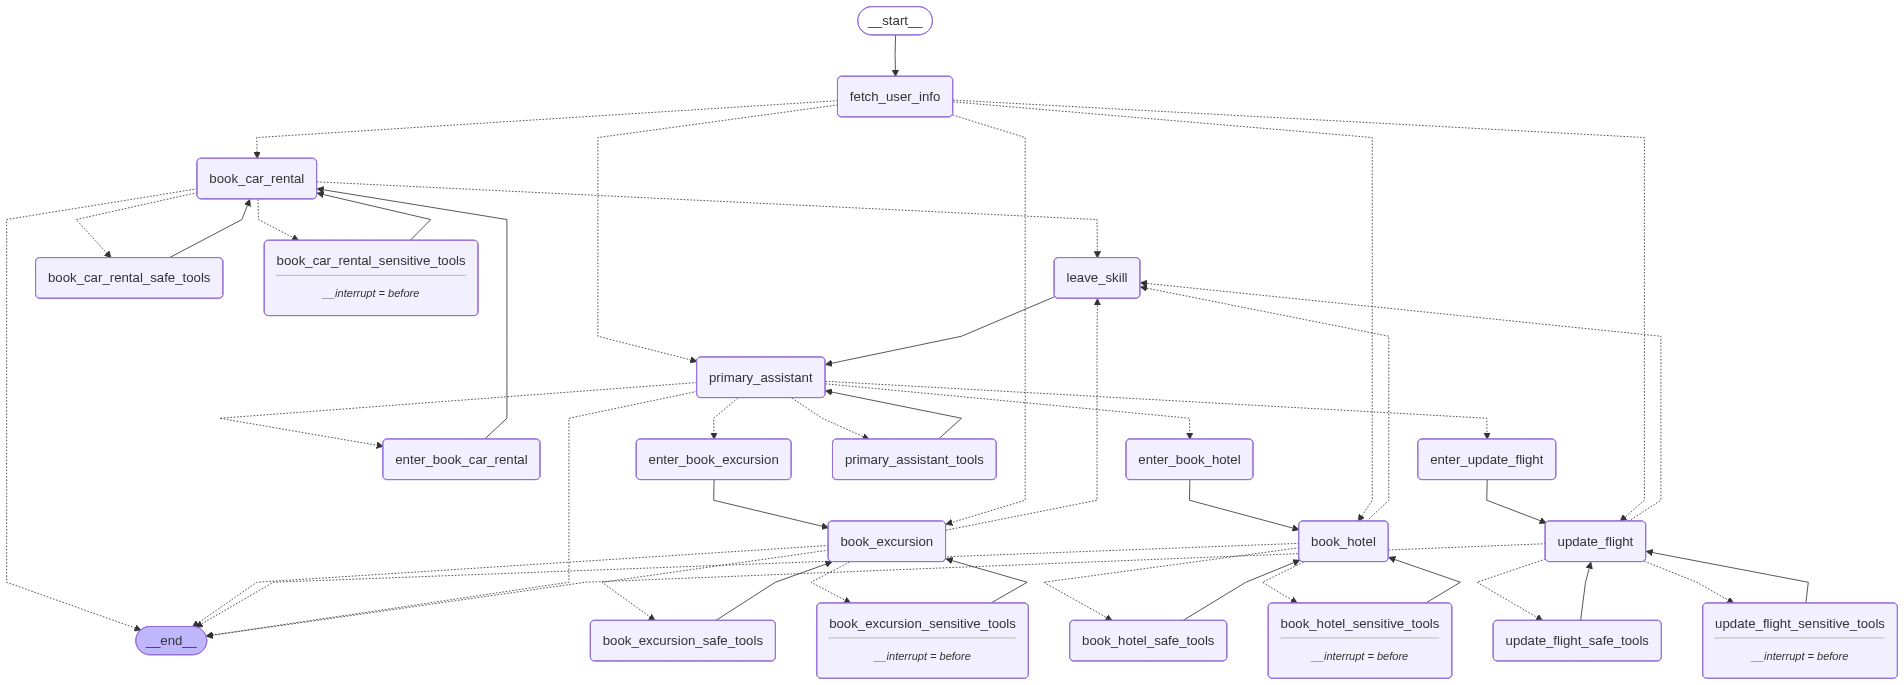

In [67]:
# Primary assistant
from IPython.display import Image, display

builder.add_node("primary_assistant", Assistant(assistant_runnable))
builder.add_node(
    "primary_assistant_tools", create_tool_node_with_fallback(primary_assistant_tools)
)


def route_primary_assistant(
    state: State,
):
    route = tools_condition(state)
    if route == END:
        return END
    tool_calls = state["messages"][-1].tool_calls
    if tool_calls:
        if tool_calls[0]["name"] == ToFlightBookingAssistant.__name__:
            return "enter_update_flight"
        elif tool_calls[0]["name"] == ToBookCarRental.__name__:
            return "enter_book_car_rental"
        elif tool_calls[0]["name"] == ToHotelBookingAssistant.__name__:
            return "enter_book_hotel"
        elif tool_calls[0]["name"] == ToBookExcursion.__name__:
            return "enter_book_excursion"
        return "primary_assistant_tools"
    raise ValueError("Invalid route")


# The assistant can route to one of the delegated assistants,
# directly use a tool, or directly respond to the user
builder.add_conditional_edges(
    "primary_assistant",
    route_primary_assistant,
    [
        "enter_update_flight",
        "enter_book_car_rental",
        "enter_book_hotel",
        "enter_book_excursion",
        "primary_assistant_tools",
        END,
    ],
)
builder.add_edge("primary_assistant_tools", "primary_assistant")


# Each delegated workflow can directly respond to the user
# When the user responds, we want to return to the currently active workflow
def route_to_workflow(
    state: State,
) -> Literal[
    "primary_assistant",
    "update_flight",
    "book_car_rental",
    "book_hotel",
    "book_excursion",
]:
    """If we are in a delegated state, route directly to the appropriate assistant."""
    dialog_state = state.get("dialog_state")
    if not dialog_state:
        return "primary_assistant"
    return dialog_state[-1]


builder.add_conditional_edges("fetch_user_info", route_to_workflow)

# Compile graph
memory = InMemorySaver()
part_4_graph = builder.compile(
    checkpointer=memory,
    # Let the user approve or deny the use of sensitive tools
    interrupt_before=[
        "update_flight_sensitive_tools",
        "book_car_rental_sensitive_tools",
        "book_hotel_sensitive_tools",
        "book_excursion_sensitive_tools",
    ],
)

display(Image(part_4_graph.get_graph(xray=True).draw_mermaid_png()))

Vamo ver o bichão conversando

In [68]:
import shutil
import uuid

# Update with the backup file so we can restart from the original place in each section
db = update_dates(db)
thread_id = str(uuid.uuid4())

config = {
    "configurable": {
        # The passenger_id is used in our flight tools to
        # fetch the user's flight information
        "passenger_id": "3442 587242",
        # Checkpoints are accessed by thread_id
        "thread_id": thread_id,
    }
}

_printed = set()


questions = [
    "Olá, que horas é o meu voo?",
    "Posso atualizar meu voo para algo mais cedo? Quero viajar ainda hoje.",
    "Então atualize meu voo para algum momento da próxima semana",
    "A próxima opção disponível está ótima",
    "E quanto a hospedagem e transporte?",
    "Sim, acho que gostaria de um hotel acessível para minha estadia de uma semana (7 dias). E vou querer alugar um carro.",
    "OK, você poderia fazer uma reserva no hotel recomendado? Parece bom.",
    "Sim, vá em frente e reserve qualquer coisa com preço moderado e disponibilidade.",
    "Agora para um carro, quais são minhas opções?",
    "Perfeito, vamos pegar a opção mais barata. Vá em frente e reserve por 7 dias",
    "Legal, então quais recomendações você tem para excursões?",
    "Elas estão disponíveis enquanto eu estiver lá?",
    "Interessante - gosto de museus, que opções há?",
    "OK ótimo, escolha um e reserve para meu segundo dia lá.",
]


for question in questions:
    events = part_4_graph.stream(
        {"messages": ("user", question)}, config, stream_mode="values"
    )
    for event in events:
        _print_event(event, _printed)
    snapshot = part_4_graph.get_state(config)
    while snapshot.next:
        # We have an interrupt! The agent is trying to use a tool, and the user can approve or deny it
        # Note: This code is all outside of your graph. Typically, you would stream the output to a UI.
        # Then, you would have the frontend trigger a new run via an API call when the user has provided input.
        try:
            user_input = input(
                "Do you approve of the above actions? Type 'y' to continue;"
                " otherwise, explain your requested changed.\n\n"
            )
        except:
            user_input = "y"
        if user_input.strip() == "y":
            # Just continue
            result = part_4_graph.invoke(
                None,
                config,
            )
        else:
            # Satisfy the tool invocation by
            # providing instructions on the requested changes / change of mind
            result = part_4_graph.invoke(
                {
                    "messages": [
                        ToolMessage(
                            tool_call_id=event["messages"][-1].tool_calls[0]["id"],
                            content=f"API call denied by user. Reasoning: '{user_input}'. Continue assisting, accounting for the user's input.",
                        )
                    ]
                },
                config,
            )
        snapshot = part_4_graph.get_state(config)

================================ Human Message =================================

Olá, que horas é o meu voo?
================================== Ai Message ==================================

Seu voo, com o número LX0112, está programado para decolar hoje, 1º de janeiro de 2026, às 22:47 (horário local). Como o horário atual é 22:43, seu voo partirá em aproximadamente 4 minutos.
================================ Human Message =================================

Posso atualizar meu voo para algo mais cedo? Quero viajar ainda hoje.
================================== Ai Message ==================================
Tool Calls:
  ToFlightBookingAssistant (call_XIxvg5dlSSp534vPk7Havrt5)
 Call ID: call_XIxvg5dlSSp534vPk7Havrt5
  Args:
    request: O cliente deseja atualizar o voo LX0112, que está programado para decolar hoje às 22:47, para um horário mais cedo ainda hoje.
Currently in:  update_flight
================================= Tool Message =================================

The assistant i